# PyTorch MNIST Experiment 🔥

## Goal
Understand how to:
- Load dataset using DataLoader
- Pass data through model
- Train a neural network
- Track loss and accuracy

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import sys
import os

# fix import path
sys.path.append(os.path.abspath('../src'))

from dataset import get_data_loader
from model import neuralNet

In [2]:
train_loader, test_loader = get_data_loader(batch_size=32)

# check one batch
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels:", labels[:10])

100.0%
100.0%
100.0%
100.0%

Image shape: torch.Size([32, 1, 28, 28])
Labels: tensor([9, 8, 3, 1, 2, 0, 7, 2, 5, 3])


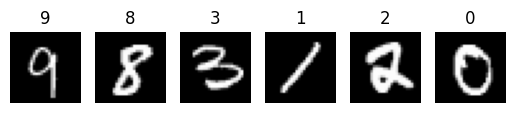

In [3]:
fig, axes = plt.subplots(1, 6)

for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(labels[i].item())
    axes[i].axis('off')

plt.show()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = neuralNet().to(device)

print(model)

neuralNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [6]:
epochs = 3

losses = []

for epoch in range(epochs):
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # flatten
        images = images.view(images.size(0), -1)

        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.2958
Epoch 2, Loss: 0.1306
Epoch 3, Loss: 0.0907


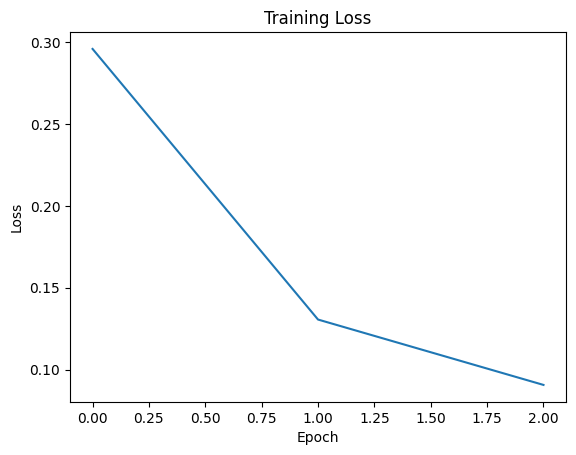

In [7]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [8]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        images = images.view(images.size(0), -1)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9726


## Observations

- Loss decreases over epochs → model is learning
- Model achieves good accuracy on MNIST
- PyTorch simplifies backpropagation using autograd

## Key Learning

- Difference between manual NN and PyTorch
- Importance of DataLoader and batching
- How training loop works in real projects